# S5 — Multi-Observation Localization Analysis (1800 UTC)

**Research question:** how does the localization scale affect analysis quality when
*all* observations in the reflectivity sweep are assimilated simultaneously?

**Key difference from S4:** in the multi-obs experiments the RMSE is evaluated over
the *full 3D domain* (558 × 898 × 11 grid points), which is **identical for every
localization scale**. This makes the localization comparison fully fair — unlike the
single-observation sweep in S4 where the evaluation domain grows with the localization
radius (larger loc → more updated grid points).

**Setup:**
- Assimilation time: 1800 UTC  
- Ensemble size: Ne = 40, truth member: tm00  
- Method: TEnKF (Nt ∈ {1, 2, 3, 5})  
- Localization scales: 0.5 – 5.0 km (10 values)  
- RMSE source: `abs_err_f_field` and `abs_err_a_field` (full 3D domain, per variable)

In [26]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'font.size': 10,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'legend.fontsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
})

# ── Palette and styles (consistent with S4) ───────────────────────────────────
LOC_SCALES = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
LOC_COLORS = {
    0.5: '#d62728', 1.0: '#ff7f0e', 1.5: '#2ca02c', 2.0: '#1f77b4',
    2.5: '#9467bd', 3.0: '#8c564b', 3.5: '#e377c2', 4.0: '#7f7f7f',
    4.5: '#bcbd22', 5.0: '#17becf'
}
LOC_LABELS = {l: f'loc = {l} km' for l in LOC_SCALES}

NTEMPS       = [1, 2, 3, 5]
NTEMP_STYLES = {1: '-', 2: '--', 3: ':', 5: '-.'}
NTEMP_COLORS = {1: 'black', 2: '#2196F3', 3: '#FF9800', 5: '#9C27B0'}

MULTIOBS_VARS = ['qg', 'qr', 'qs', 'T', 'P', 'u', 'v', 'w']

DATA_ROOT = '/home/jorge.gacitua/datosmunin/WRF_Single_Cycle_Assimilation/data'

print('Imports and palettes ready.')

Imports and palettes ready.


## S0. Data Loading

For each localization scale and ntemp, we load the 3D absolute-error fields
(`abs_err_f_field`, `abs_err_a_field`) and compute RMSE over three evaluation domains:

1. **Global** — all valid (non-NaN) grid points (558 × 898 × 11)
2. **Obs-location** — only the grid points at observation locations (`ix`, `iy`, `iz`
   from the reference file)
3. **Storm region** — grid points where the truth reflectivity exceeds a threshold

All three domains are **identical across localization scales** → fair comparison.

In [10]:
# ── Reference data (truth, prior mean, obs locations) ─────────────────────────
# We use LOC4.0 as the representative reference (any loc gives the same truth/prior).
REF_LOC    = 4.0
STORM_REFL_THRESH = 20.0   # dBZ threshold for 'storm region' evaluation domain

ref_folder = os.path.join(DATA_ROOT, f'WS_multiobs_1800_LOC{REF_LOC}')
ref_file   = os.path.join(ref_folder,
    f'WS_multiobs_1800_LOC{REF_LOC}_multi_obs_ref_Ne040_tm00.npz')

ref_data = np.load(ref_file, allow_pickle=True)
truth    = ref_data['truth']    # (558, 898, 11, 8) — truth state per variable
xf_mean  = ref_data['xf_mean'] # (558, 898, 11, 8) — prior ensemble mean
yo_clean = ref_data['yo_clean'] # (n_obs,)           — observation values
obs_ix   = ref_data['ix'].astype(int)  # observation grid indices
obs_iy   = ref_data['iy'].astype(int)
obs_iz   = ref_data['iz'].astype(int)

print(f'Truth shape:   {truth.shape}')
print(f'Prior shape:   {xf_mean.shape}')
print(f'Observations:  {len(yo_clean):,} obs points')
print(f'Variable order: {MULTIOBS_VARS}')

# ── Build evaluation domain masks ─────────────────────────────────────────────
# 3D bool array: which (i,j,k) points to include in storm-region RMSE
# Approximate truth reflectivity from qr, qg, qs (simple linear proxy)
truth_qr = truth[..., 1]   # qr index 1
truth_qg = truth[..., 0]   # qg index 0
truth_qs = truth[..., 2]   # qs index 2
# Simplified reflectivity proxy (not a proper Z-M relation, just order-of-magnitude)
# Use the truth_hx_field from the TEnKF file instead (computed by forward operator)
# We'll build the storm mask from the obs-location reflectivity

# Build obs-location mask as a boolean 3D volume
obs_mask_3d = np.zeros((truth.shape[0], truth.shape[1], truth.shape[2]), dtype=bool)
obs_mask_3d[obs_ix, obs_iy, obs_iz] = True
print(f'Obs-location points in 3D grid: {obs_mask_3d.sum():,}')

Truth shape:   (558, 898, 11, 8)
Prior shape:   (558, 898, 11, 8)
Observations:  693,783 obs points
Variable order: ['obs', 'qg', 'qr', 'qs', 'T', 'P', 'u', 'v', 'w']
Obs-location points in 3D grid: 693,783


In [27]:
# ── Helper: compute RMSE from abs_err field over a domain ────────────────────
def field_rmse(abs_err, domain_mask=None):
    """RMSE of abs_err over domain_mask (all valid points if None). Returns array of shape (8,)."""
    rmse = np.full(abs_err.shape[-1], np.nan)
    for vi in range(abs_err.shape[-1]):
        field = abs_err[..., vi]               # (nx, ny, nz)
        if domain_mask is not None:
            vals = field[domain_mask]
        else:
            vals = field[np.isfinite(field)]
        if len(vals) > 0:
            rmse[vi] = np.sqrt(np.nanmean(vals ** 2))
    return rmse


# ── Build storm-region mask using truth_hx_field from a reference TEnKF file ─
ref_tenk = np.load(os.path.join(ref_folder,
    f'WS_multiobs_1800_LOC{REF_LOC}_multi_obs_TEnKF_Nt01_as1.0_'
    f'Lx{REF_LOC}Ly{REF_LOC}Lz{REF_LOC}_Ne040_tm00.npz'), allow_pickle=True)
truth_hx = ref_tenk['truth_hx_field']  # (558, 898, 11)  — truth reflectivity at obs locs

# Storm mask: any z-level has truth reflectivity > threshold
storm_mask_2d = np.nanmax(truth_hx, axis=2) >= STORM_REFL_THRESH  # (558, 898) bool
storm_mask_3d = np.broadcast_to(storm_mask_2d[:, :, np.newaxis],
                                 truth_hx.shape)                   # (558, 898, 11)
print(f'Storm-region columns (max refl ≥ {STORM_REFL_THRESH} dBZ): '
      f'{storm_mask_2d.sum():,} / {storm_mask_2d.size:,}')
print(f'Storm-region 3D points: {storm_mask_3d.sum():,}')


# ── Main loading loop ─────────────────────────────────────────────────────────
records = []

for loc in LOC_SCALES:
    folder = os.path.join(DATA_ROOT, f'WS_multiobs_1800_LOC{loc}')
    for nt in NTEMPS:
        l_str = str(loc)
        fname = (f'WS_multiobs_1800_LOC{l_str}_multi_obs_TEnKF_'
                 f'Nt0{nt}_as1.0_Lx{l_str}Ly{l_str}Lz{l_str}_Ne040_tm00.npz')
        fpath = os.path.join(folder, fname)
        if not os.path.exists(fpath):
            print(f'  MISSING: {fname}')
            continue

        d = np.load(fpath, allow_pickle=True)
        abs_f = d['abs_err_f_field']  # (558, 898, 11, 8)
        abs_a = d['abs_err_a_field']

        # Get storm mask for this file's truth_hx
        this_hx    = d['truth_hx_field']                            # (558, 898, 11)
        storm_mask = np.broadcast_to(
            (np.nanmax(this_hx, axis=2) >= STORM_REFL_THRESH)[:, :, np.newaxis],
            this_hx.shape)

        rmse_f_global = field_rmse(abs_f)
        rmse_a_global = field_rmse(abs_a)
        rmse_f_storm  = field_rmse(abs_f, storm_mask)
        rmse_a_storm  = field_rmse(abs_a, storm_mask)
        rmse_f_obs    = field_rmse(abs_f, obs_mask_3d)
        rmse_a_obs    = field_rmse(abs_a, obs_mask_3d)

        row = {'loc_scale': loc, 'ntemp': nt}
        for vi, vn in enumerate(MULTIOBS_VARS):
            row[f'rmse_f_global_{vn}'] = rmse_f_global[vi]
            row[f'rmse_a_global_{vn}'] = rmse_a_global[vi]
            row[f'drmse_global_{vn}']  = rmse_a_global[vi] - rmse_f_global[vi]
            row[f'rmse_f_storm_{vn}']  = rmse_f_storm[vi]
            row[f'rmse_a_storm_{vn}']  = rmse_a_storm[vi]
            row[f'drmse_storm_{vn}']   = rmse_a_storm[vi] - rmse_f_storm[vi]
            row[f'rmse_f_obs_{vn}']    = rmse_f_obs[vi]
            row[f'rmse_a_obs_{vn}']    = rmse_a_obs[vi]
            row[f'drmse_obs_{vn}']     = rmse_a_obs[vi] - rmse_f_obs[vi]
        records.append(row)

    print(f'loc={loc}: loaded {sum(1 for r in records if r["loc_scale"]==loc)} files')

df_multi = pd.DataFrame(records)
print(f'\nTotal rows: {len(df_multi)}')
print(f'loc_scale: {sorted(df_multi.loc_scale.unique())}')
print(f'ntemp:     {sorted(df_multi.ntemp.unique())}')

Storm-region columns (max refl ≥ 20.0 dBZ): 39,474 / 501,084
Storm-region 3D points: 434,214
loc=0.5: loaded 4 files
loc=1.0: loaded 4 files
loc=1.5: loaded 4 files
loc=2.0: loaded 4 files
loc=2.5: loaded 4 files
loc=3.0: loaded 4 files
loc=3.5: loaded 4 files
loc=4.0: loaded 4 files
loc=4.5: loaded 4 files
loc=5.0: loaded 4 files

Total rows: 40
loc_scale: [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
ntemp:     [1, 2, 3, 5]


## 1. DRMSE vs Localization Scale — All Variables

Each panel shows one state variable. Lines = ntemp values.
A horizontal dashed line at 0 separates improvement (negative dRMSE) from degradation.
Three domain choices available: **global**, **storm region**, **obs locations**.

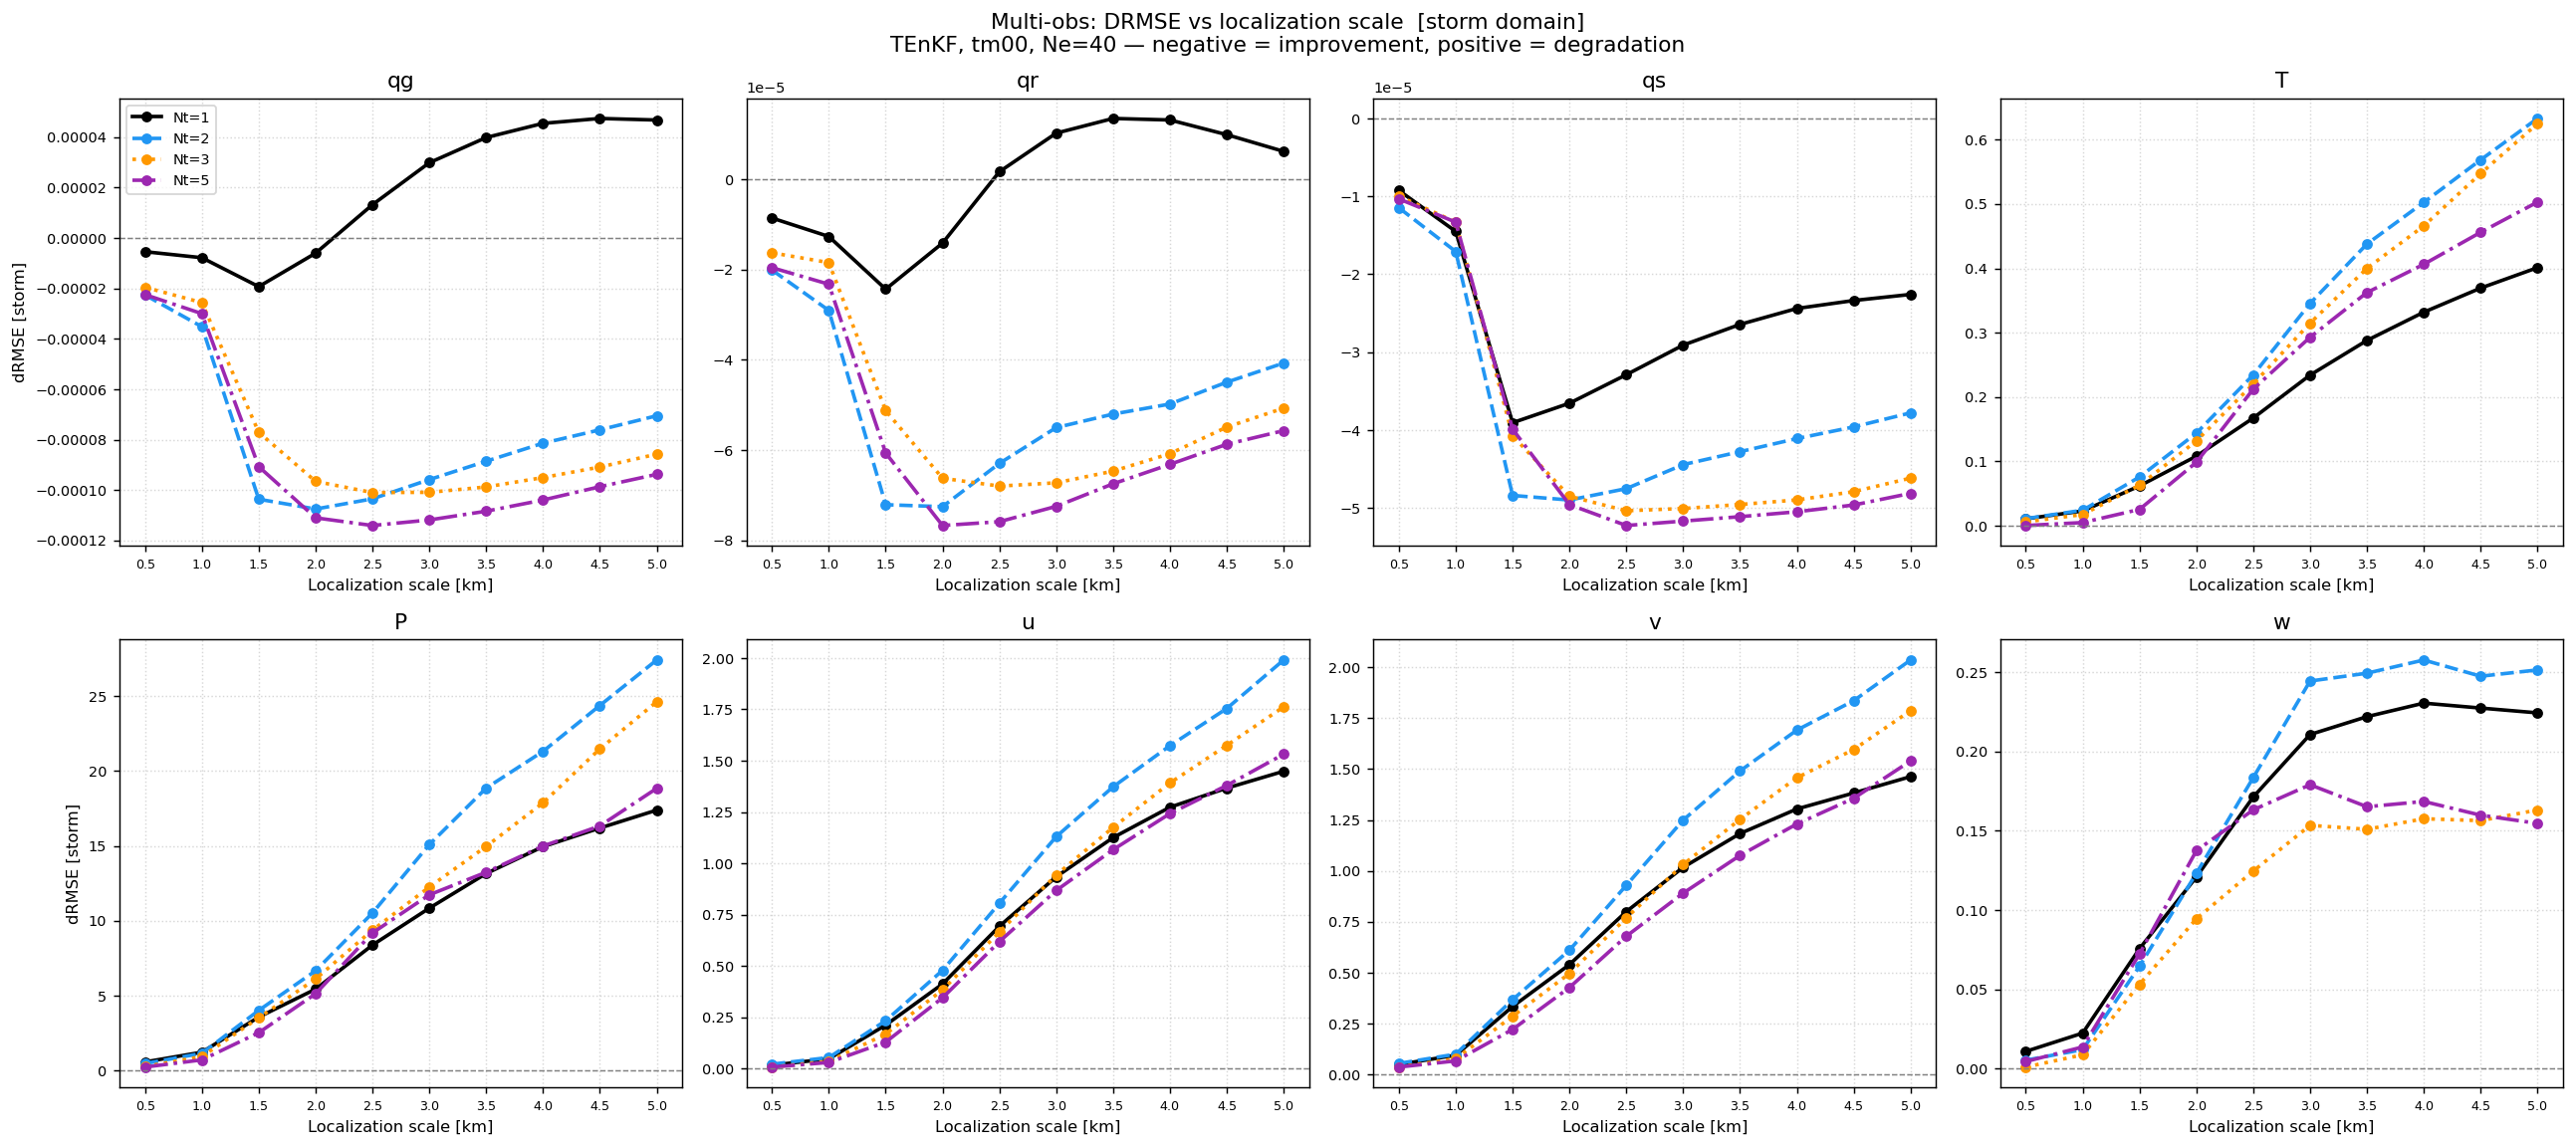

In [4]:
DOMAIN = 'storm'   # choose: 'global', 'storm', or 'obs'

n_cols = 4
n_rows = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows))
fig.suptitle(f'Multi-obs: DRMSE vs localization scale  [{DOMAIN} domain]\n'
             f'TEnKF, tm00, Ne=40 — negative = improvement, positive = degradation',
             fontsize=12)
axes = axes.flatten()

loc_arr = sorted(df_multi.loc_scale.unique())

for vi, vn in enumerate(MULTIOBS_VARS):
    ax = axes[vi]
    col = f'drmse_{DOMAIN}_{vn}'

    for nt in NTEMPS:
        sub = df_multi[df_multi.ntemp == nt].sort_values('loc_scale')
        ax.plot(sub['loc_scale'], sub[col],
                color=NTEMP_COLORS[nt], linestyle=NTEMP_STYLES[nt],
                marker='o', markersize=5, linewidth=2, label=f'Nt={nt}')

    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_title(vn, fontsize=12)
    ax.set_xlabel('Localization scale [km]')
    ax.set_xticks(loc_arr)
    ax.set_xticklabels([str(l) for l in loc_arr], fontsize=7)
    ax.grid(True, linestyle=':', alpha=0.5)
    if vi % n_cols == 0:
        ax.set_ylabel(f'dRMSE [{DOMAIN}]')
    if vi == 0:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

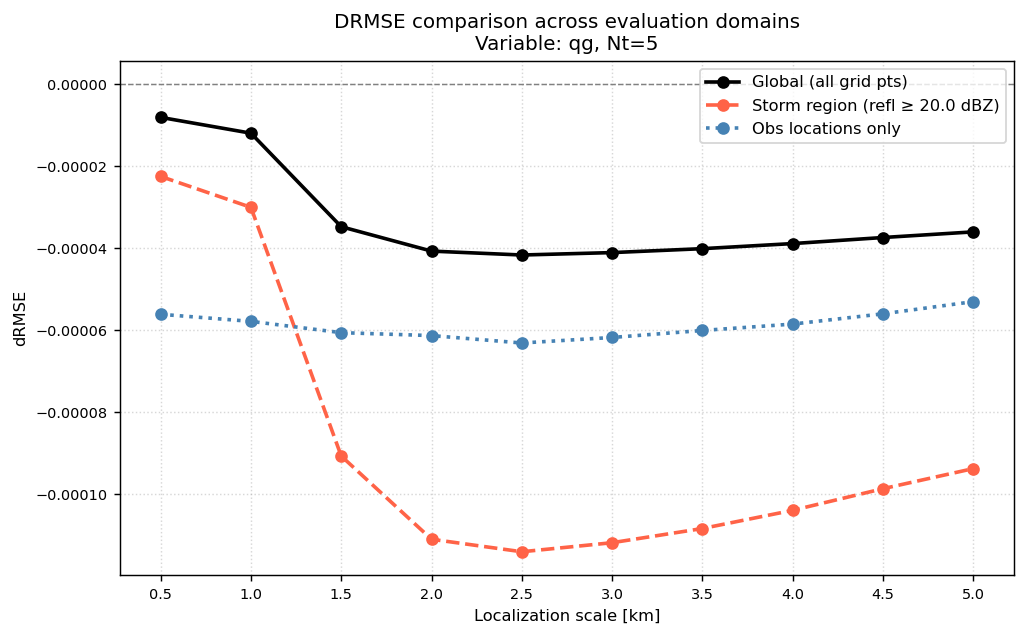

In [24]:
# ── Compare all three evaluation domains for one variable and one ntemp ───────
VAR_COMPARE  = 'qg'   # change to any variable in MULTIOBS_VARS
NT_COMPARE   = 5

fig, ax = plt.subplots(figsize=(8, 5))
sub = df_multi[df_multi.ntemp == NT_COMPARE].sort_values('loc_scale')

domain_styles = {
    'global': ('-',  'black',     'Global (all grid pts)'),
    'storm':  ('--', 'tomato',    f'Storm region (refl ≥ {STORM_REFL_THRESH} dBZ)'),
    'obs':    (':',  'steelblue', 'Obs locations only'),
}
for dom, (ls, col, lbl) in domain_styles.items():
    ax.plot(sub['loc_scale'], sub[f'drmse_{dom}_{VAR_COMPARE}'],
            color=col, linestyle=ls, marker='o', markersize=6,
            linewidth=2, label=lbl)

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_title(f'DRMSE comparison across evaluation domains\n'
             f'Variable: {VAR_COMPARE}, Nt={NT_COMPARE}', fontsize=11)
ax.set_xlabel('Localization scale [km]')
ax.set_ylabel('dRMSE')
ax.set_xticks(sorted(df_multi.loc_scale.unique()))
ax.legend(fontsize=9)
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

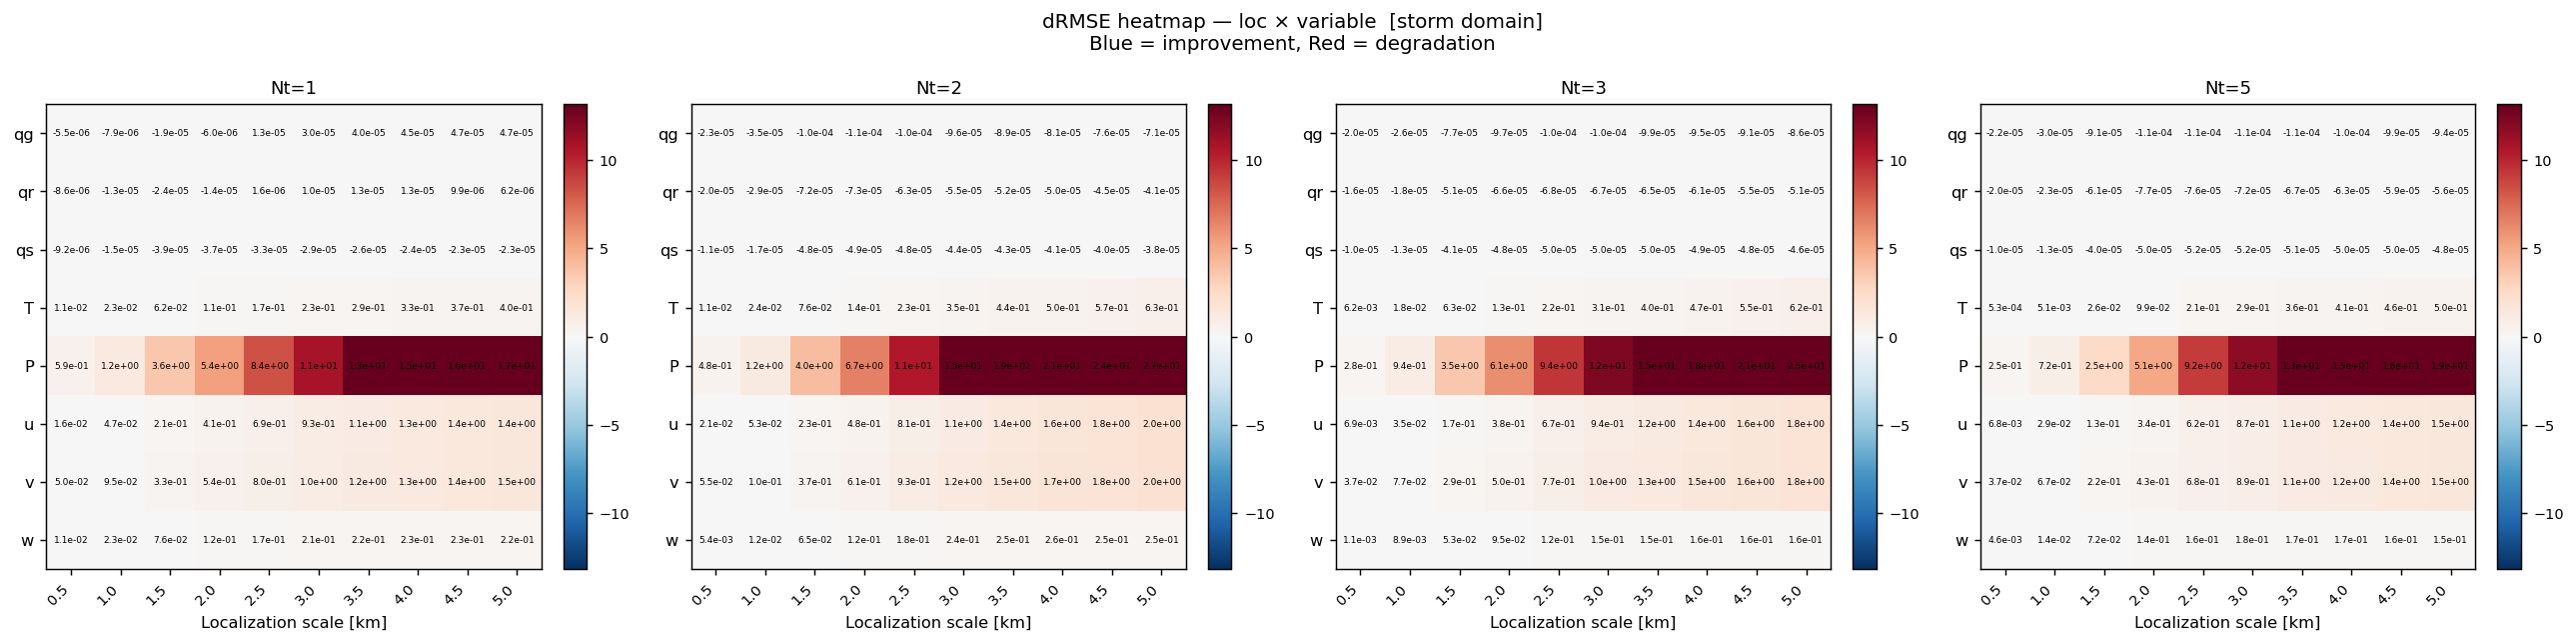

In [6]:
# ── Heatmap: dRMSE(loc, var) for each ntemp ──────────────────────────────────
import matplotlib.colors as mcolors

DOMAIN_HM = 'storm'

fig, axes = plt.subplots(1, len(NTEMPS), figsize=(5 * len(NTEMPS), 5), squeeze=False)
fig.suptitle(f'dRMSE heatmap — loc × variable  [{DOMAIN_HM} domain]\n'
             'Blue = improvement, Red = degradation', fontsize=11)

all_drmse = np.array([
    [df_multi[(df_multi.ntemp == nt) & (df_multi.loc_scale == loc)]
              [f'drmse_{DOMAIN_HM}_{vn}'].values[0]
     for vn in MULTIOBS_VARS for loc in loc_arr]
    for nt in NTEMPS
])
vmax_hm = np.nanpercentile(np.abs(all_drmse), 95)

for ci, nt in enumerate(NTEMPS):
    ax = axes[0][ci]
    mat = np.array(
        [[df_multi[(df_multi.ntemp == nt) & (df_multi.loc_scale == loc)]
                   [f'drmse_{DOMAIN_HM}_{vn}'].values[0]
          for loc in loc_arr]
         for vn in MULTIOBS_VARS]
    )  # shape (n_vars, n_locs)

    im = ax.imshow(mat, cmap='RdBu_r',
                   norm=mcolors.TwoSlopeNorm(vcenter=0, vmin=-vmax_hm, vmax=vmax_hm),
                   aspect='auto')
    ax.set_xticks(range(len(loc_arr)))
    ax.set_xticklabels([str(l) for l in loc_arr], rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(MULTIOBS_VARS)))
    ax.set_yticklabels(MULTIOBS_VARS, fontsize=9)
    ax.set_title(f'Nt={nt}', fontsize=10)
    ax.set_xlabel('Localization scale [km]')
    plt.colorbar(im, ax=ax, orientation='vertical', fraction=0.06, pad=0.04)

    # Annotate with dRMSE values
    for ri in range(mat.shape[0]):
        for ci2 in range(mat.shape[1]):
            val = mat[ri, ci2]
            if np.isfinite(val):
                ax.text(ci2, ri, f'{val:.1e}', ha='center', va='center',
                        fontsize=5, color='k')

plt.tight_layout()
plt.show()

## 2. Fairness Discussion: Multi-obs vs. Single-Observation Experiments

### Why the single-point sweep comparison (S4) is potentially biased

In the **single-observation sweep** (S4), each experiment assimilates one observation
at a time and the RMSE is computed over all grid points that received a non-negligible
localization weight. This means:

- **loc = 0.5 km**: only ~1 grid point receives any weight → RMSE is computed from
  O(1) data points. The metric is extremely noisy and measures the *local* performance
  right at the observation.
- **loc = 5.0 km**: thousands of grid points receive weight → RMSE is computed from
  O(1000s) data points and represents the *regional* performance over a large area.

The S4 comparison therefore conflates **localization scale** with **evaluation domain**:
a worse-looking DRMSE for small loc might simply reflect noisy estimation from few points,
not worse physics.

### Why multi-obs is fairer

In the **multi-obs experiment** (S5), all reflectivity observations are assimilated
simultaneously and the RMSE is always evaluated over the *same full 3D domain* regardless
of the localization scale. This removes the sample-size bias and gives a true
apples-to-apples comparison.

However, multi-obs introduces a new question: with a very large localization, each
observation influences many of the same grid points as its neighbors, potentially causing
*over-influence* in the intersection zones. This can lead to degradation for large loc.

### Practical implications

| Experiment | Evaluation domain | Sample size varies? | Bias |
|---|---|---|---|
| S4 single-point sweep | Changes with loc | Yes — small loc = few points | Yes |
| S5 multi-obs | Fixed full domain | No | No |

The multi-obs metric is the better benchmark for choosing the operational localization scale.

In [7]:
# ── Summary table: best loc_scale per variable and ntemp ─────────────────────
DOMAIN_BEST = 'storm'

rows = []
for nt in NTEMPS:
    sub = df_multi[df_multi.ntemp == nt]
    row = {'ntemp': nt}
    for vn in MULTIOBS_VARS:
        col = f'drmse_{DOMAIN_BEST}_{vn}'
        best_idx = sub[col].idxmin(skipna=True)
        if pd.isna(best_idx):
            row[vn] = 'N/A'
        else:
            best_loc  = sub.loc[best_idx, 'loc_scale']
            best_val  = sub.loc[best_idx, col]
            row[vn]   = f'{best_loc} km ({best_val:.2e})'
    rows.append(row)

tbl = pd.DataFrame(rows).set_index('ntemp')
print(f'Best localization scale per variable (min dRMSE, {DOMAIN_BEST} domain):')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
display(tbl)

Best localization scale per variable (min dRMSE, storm domain):


,qg,qr,qs,T,P,u,v,w
ntemp,,,,,,,,
1,1.5 km (-1.93e-05),1.5 km (-2.44e-05),1.5 km (-3.91e-05),0.5 km (1.09e-02),0.5 km (5.86e-01),0.5 km (1.58e-02),0.5 km (4.98e-02),0.5 km (1.10e-02)
2,2.0 km (-1.08e-04),2.0 km (-7.25e-05),2.0 km (-4.90e-05),0.5 km (1.12e-02),0.5 km (4.82e-01),0.5 km (2.07e-02),0.5 km (5.46e-02),0.5 km (5.44e-03)
3,2.5 km (-1.01e-04),2.5 km (-6.80e-05),2.5 km (-5.04e-05),0.5 km (6.25e-03),0.5 km (2.82e-01),0.5 km (6.87e-03),0.5 km (3.69e-02),0.5 km (1.13e-03)
5,2.5 km (-1.14e-04),2.0 km (-7.67e-05),2.5 km (-5.22e-05),0.5 km (5.30e-04),0.5 km (2.46e-01),0.5 km (6.76e-03),0.5 km (3.68e-02),0.5 km (4.62e-03)
